In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torchvision
from __future__ import print_function
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torchvision.transforms as transforms

from torch.autograd import Variable
import pylab
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Standard MNIST preprocessing
transform = transforms.Compose([
    transforms.Resize(32), # Resizing to 32x32 often works better with DCGAN layers
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 102kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 933kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.94MB/s]


In [3]:
# num_gpu = 1 if torch.cuda.is_available() else 0
num_gpu = 0
# load the models
from dcgan import Discriminator, Generator

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()



In [7]:
D.load_state_dict(torch.load('weights/netD_epoch_99.pth' , map_location= torch.device('cpu')))
G.load_state_dict(torch.load('weights/netG_epoch_99.pth' , map_location= torch.device('cpu')))
if torch.cuda.is_available():
    D = D.cuda()
    G = G.cuda()

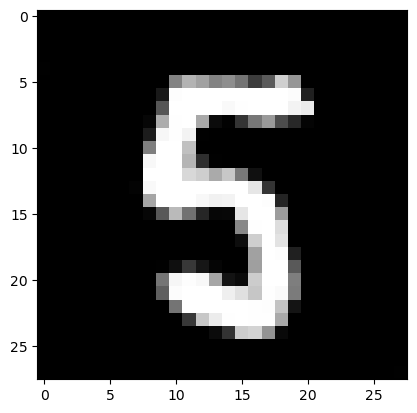

In [15]:
shit = G(torch.randn(1,100, 1,1)).detach().numpy().reshape(1,28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()

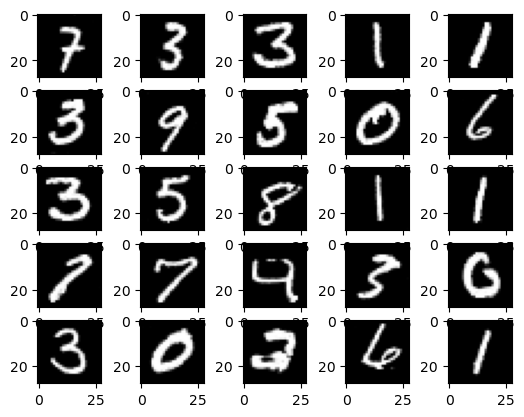

In [10]:
batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1)
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)


# z = torch.randn(batch_size, latent_size).cuda()
# z = Variable(z)
# fake_images = G(z)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 28, 28)
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.imshow(fake_images_np[i], cmap='gray')
plt.show()